# Лабораторная работа №2
## Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных.

### Выполнил студент группы РТ5-61Б Иванов А.А.

**Student Academic Performance Analysis Dataset**

https://www.kaggle.com/datasets/emanfatima2/student-academic-performance-analysis-dataset/data

Помимо важных демографических, социальных характеристик и особенностей образа жизни, которые могут влиять на успеваемость, этот набор данных включает информацию об академических успехах учащихся.  Среди переменных — пол, раса/этническая принадлежность, уровень образования родителей, тип питания, прохождение курсов подготовки к экзаменам, время, уделяемое учебе в неделю, и продолжительность сна в сутки. 

Кроме того, в наборе данных указаны результаты детей по чтению, письму и математике, что позволяет тщательно изучить тенденции в успеваемости.  К дополнительным контекстуальным факторам, проливающим свет на то, как окружающая среда влияет на успеваемость учащихся, относятся тип школы и наличие доступа к интернету.

Цель этого набора данных — помочь в проведении образовательных исследований, статистическом анализе и применении методов машинного обучения для изучения того, как индивидуальные особенности и учебные привычки влияют на успеваемость.

Импортируем необходимые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator


In [2]:
data = pd.read_csv("student_academic_performance.csv", sep=",", index_col=0)

In [3]:
data.head()

,Gender,Race/Ethnicity,Parental Education,Lunch Type,Test Preparation,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score,School Type,Internet Access
Student ID,,,,,,,,,,,,
1,female,group B,some college,standard,False,12.4,5.4,62.0,76.0,65.0,public,True
2,male,group D,high school,standard,False,18.3,5.1,74.0,73.0,76.0,public,NaN
3,male,group B,bachelor degree,free/reduced,True,11.8,7.8,71.0,83.0,91.0,public,False
4,male,group E,high school,standard,False,NaN,7.3,83.0,73.0,52.0,public,True
5,female,group C,bachelor degree,standard,True,12.9,6.3,41.0,NaN,81.0,public,True


In [4]:
print(data.shape)
print(data.dtypes)

(7000, 12)
Gender                      str
Race/Ethnicity              str
Parental Education          str
Lunch Type                  str
Test Preparation           bool
Study Time per Week     float64
Daily Sleep Duration    float64
Math Score              float64
Reading Score           float64
Writing Score           float64
School Type                 str
Internet Access          object
dtype: object


In [5]:
data["Internet Access"]=data["Internet Access"].astype(bool)
data.isnull().sum()

Gender                    0
Race/Ethnicity            0
Parental Education      700
Lunch Type              210
Test Preparation          0
Study Time per Week     630
Daily Sleep Duration    560
Math Score                0
Reading Score           490
Writing Score           350
School Type               0
Internet Access           0
dtype: int64

In [6]:
data.describe()

,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score
count,6370.000000,6440.000000,7000.000000,6510.000000,6650.000000
mean,9.662653,7.193587,69.476571,71.134101,70.460451
std,4.681971,1.316991,14.782909,13.818268,13.699283
min,0.000000,3.000000,3.000000,21.000000,14.000000
25%,6.400000,6.300000,59.000000,62.000000,61.000000
50%,9.600000,7.200000,70.000000,71.000000,71.000000
75%,12.800000,8.100000,80.000000,81.000000,80.000000
max,26.100000,11.000000,100.000000,100.000000,100.000000


In [7]:
for col in data.select_dtypes("str"):
    print('{} - {}'.format(col, data[col].unique()))

Gender - <StringArray>
['female', 'male']
Length: 2, dtype: str
Race/Ethnicity - <StringArray>
['group B', 'group D', 'group E', 'group C', 'group A']
Length: 5, dtype: str
Parental Education - <StringArray>
[    'some college',      'high school',  'bachelor degree',
 'associate degree',    'master degree',                nan]
Length: 6, dtype: str
Lunch Type - <StringArray>
['standard', 'free/reduced', nan]
Length: 3, dtype: str
School Type - <StringArray>
['public', 'private', 'international']
Length: 3, dtype: str


In [8]:
data.isnull().sum() * 100 / len(data)


Gender                   0.0
Race/Ethnicity           0.0
Parental Education      10.0
Lunch Type               3.0
Test Preparation         0.0
Study Time per Week      9.0
Daily Sleep Duration     8.0
Math Score               0.0
Reading Score            7.0
Writing Score            5.0
School Type              0.0
Internet Access          0.0
dtype: float64

Обработка пропусков в числовых данных

In [9]:
num_cols = []
for col in data.columns:
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / data.shape[0]) * 100.0, 2)



In [10]:
data_num = data[num_cols]
data_num

,Study Time per Week,Daily Sleep Duration,Reading Score,Writing Score
Student ID,,,,
1,12.4,5.4,76.0,65.0
2,18.3,5.1,73.0,76.0
3,11.8,7.8,83.0,91.0
4,NaN,7.3,73.0,52.0
5,12.9,6.3,NaN,81.0
...,...,...,...,...
6996,3.5,6.8,NaN,50.0
6997,10.8,7.3,52.0,81.0
6998,12.7,6.9,NaN,59.0


Заполним пропуски в числовых колонках медианой

In [11]:
from sklearn.impute import SimpleImputer

strategies=['mean', 'median', 'most_frequent']
columns_to_impute = ['Study Time per Week', 'Daily Sleep Duration', 'Reading Score', 'Writing Score']

data_filled_nums = data.copy()

for col in columns_to_impute:
    imp_median = SimpleImputer(strategy='median')
    data_filled_nums[col] = imp_median.fit_transform(data_filled_nums[[col]])

# Проверка наличия пропущенных значений после заполнения
print(data_filled_nums[columns_to_impute].isnull().sum())


Study Time per Week     0
Daily Sleep Duration    0
Reading Score           0
Writing Score           0
dtype: int64


Обработка пропусков в категориальных колонках
Заполним пропуски наиболее частыми категориями

In [12]:
columns_to_impute_category = ['Parental Education', 'Lunch Type']
data_filled = data_filled_nums.copy()


for col in columns_to_impute_category:
    imp_fr = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
    data_filled[col] = imp_fr.fit_transform(data_filled[[col]]).ravel()

print(data_filled[columns_to_impute_category].isnull().sum())

Parental Education    0
Lunch Type            0
dtype: int64


Кодирование категориальных признаков.

In [13]:
data_oe=data_filled.copy()

data_oe=pd.get_dummies(data_oe)
data_oe

,Test Preparation,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score,Internet Access,Gender_female,Gender_male,Race/Ethnicity_group A,...,Parental Education_associate degree,Parental Education_bachelor degree,Parental Education_high school,Parental Education_master degree,Parental Education_some college,Lunch Type_free/reduced,Lunch Type_standard,School Type_international,School Type_private,School Type_public
Student ID,,,,,,,,,,,,,,,,,,,,,
1,False,12.4,5.4,62.0,76.0,65.0,True,True,False,False,...,False,False,False,False,True,False,True,False,False,True
2,False,18.3,5.1,74.0,73.0,76.0,True,False,True,False,...,False,False,True,False,False,False,True,False,False,True
3,True,11.8,7.8,71.0,83.0,91.0,False,False,True,False,...,False,True,False,False,False,True,False,False,False,True
4,False,9.6,7.3,83.0,73.0,52.0,True,False,True,False,...,False,False,True,False,False,False,True,False,False,True
5,True,12.9,6.3,41.0,71.0,81.0,True,True,False,False,...,False,True,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6996,True,3.5,6.8,74.0,71.0,50.0,False,True,False,False,...,False,False,False,False,True,False,True,False,True,False
6997,True,10.8,7.3,82.0,52.0,81.0,True,True,False,True,...,True,False,False,False,False,True,False,False,False,True
6998,False,12.7,6.9,78.0,71.0,59.0,True,True,False,False,...,False,False,True,False,False,False,True,False,False,True


Масштабирование данных

In [14]:
from sklearn.preprocessing import StandardScaler

columns_num = ['Study Time per Week', 'Daily Sleep Duration', 'Reading Score', 'Writing Score', 'Math Score']

scaler = StandardScaler()
data_oe[columns_num] = scaler.fit_transform(data_oe[columns_num])

final_data=data_oe.copy()
final_data.head()

,Test Preparation,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score,Internet Access,Gender_female,Gender_male,Race/Ethnicity_group A,...,Parental Education_associate degree,Parental Education_bachelor degree,Parental Education_high school,Parental Education_master degree,Parental Education_some college,Lunch Type_free/reduced,Lunch Type_standard,School Type_international,School Type_private,School Type_public
Student ID,,,,,,,,,,,,,,,,,,,,,
1,False,0.614193,-1.420376,-0.505794,0.365879,-0.410984,True,True,False,False,...,False,False,False,False,True,False,True,False,False,True
2,False,1.935285,-1.657883,0.306012,0.140736,0.412867,True,False,True,False,...,False,False,True,False,False,False,True,False,False,True
3,True,0.479844,0.479686,0.103061,0.891212,1.536301,False,False,True,False,...,False,True,False,False,False,True,False,False,False,True
4,False,-0.012766,0.083840,0.914867,0.140736,-1.384627,True,False,True,False,...,False,False,True,False,False,False,True,False,False,True
5,True,0.726150,-0.707852,-1.926455,-0.009360,0.787345,True,True,False,False,...,False,True,False,False,False,False,True,False,False,True


In [15]:
final_data.describe()

,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score
count,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03
mean,-1.136868e-16,-4.877368e-16,-2.596019e-16,-3.684672e-16,3.907985e-16
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-2.162340e+00,-3.320437e+00,-4.497175e+00,-3.761740e+00,-4.230659e+00
25%,-6.621167e-01,-6.286830e-01,-7.087455e-01,-6.097404e-01,-6.356709e-01
50%,-1.276629e-02,4.670986e-03,3.541021e-02,-9.359509e-03,3.838933e-02
75%,6.141928e-01,6.380250e-01,7.119154e-01,6.660689e-01,6.375540e-01
max,3.681814e+00,3.013102e+00,2.064926e+00,2.167021e+00,2.210361e+00


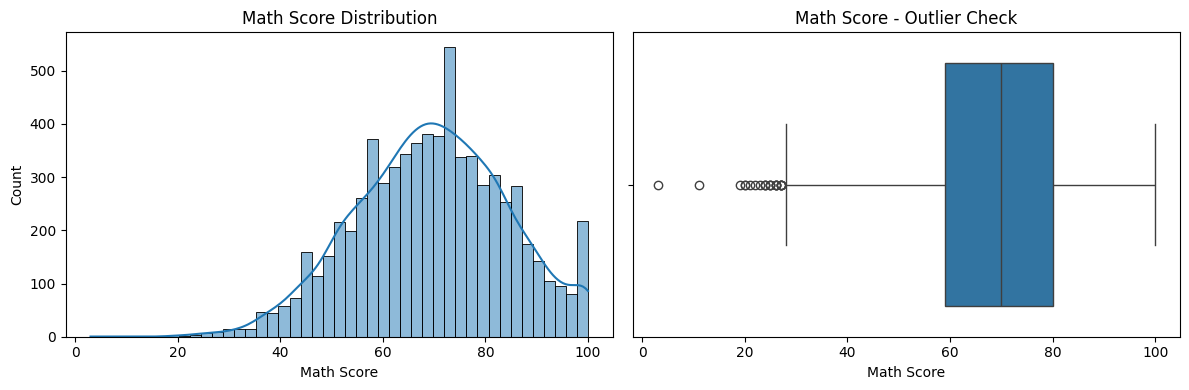

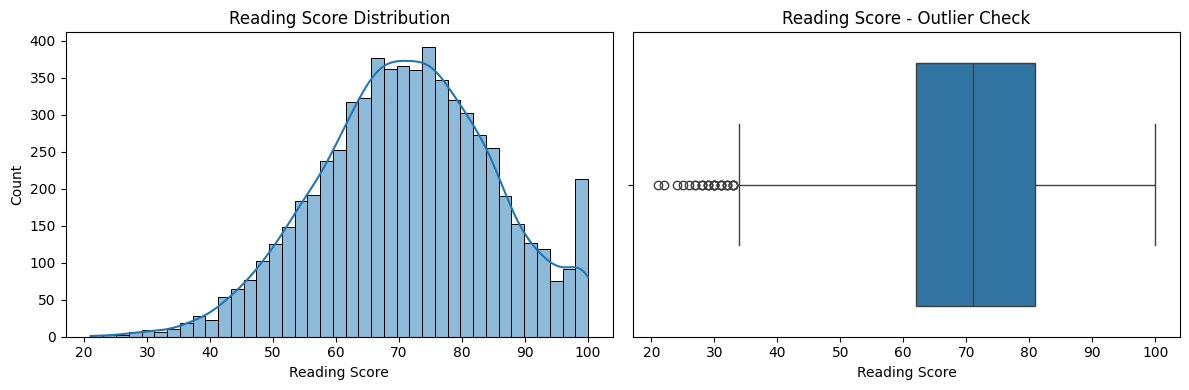

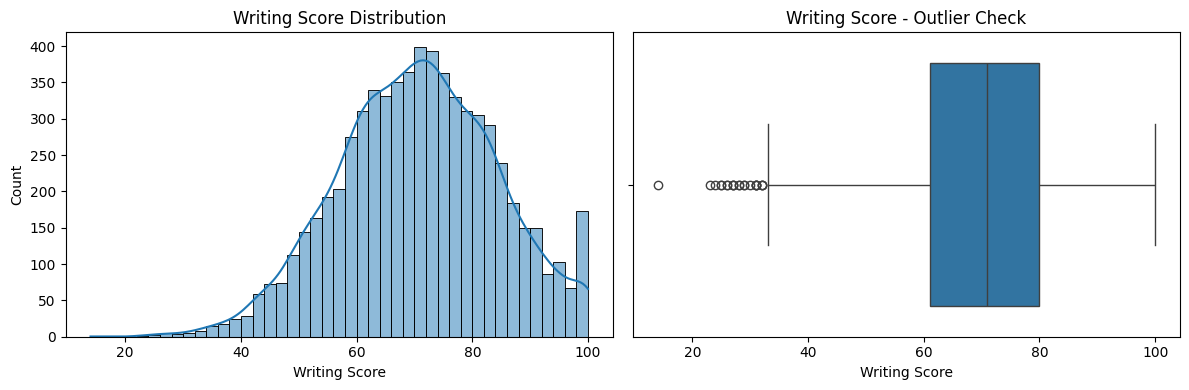

In [16]:
cols = ['Math Score', 'Reading Score', 'Writing Score']

for col in cols:
    fig, axes = plt.subplots(1,2, figsize=(12,4))

    # Histogram
    sns.histplot(data=data, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f"{col} Distribution")

    # Boxplot
    sns.boxplot(data=data, x=col, ax=axes[1])
    axes[1].set_title(f"{col} - Outlier Check")

    plt.tight_layout()
    plt.show()

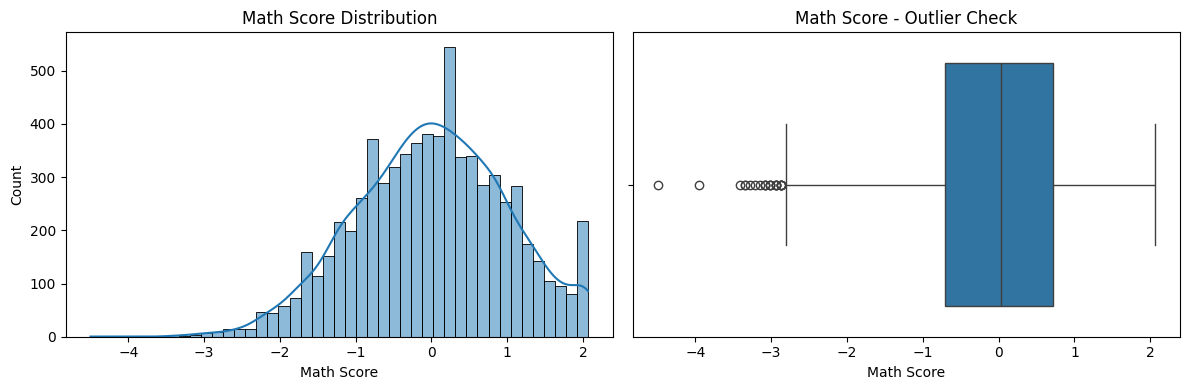

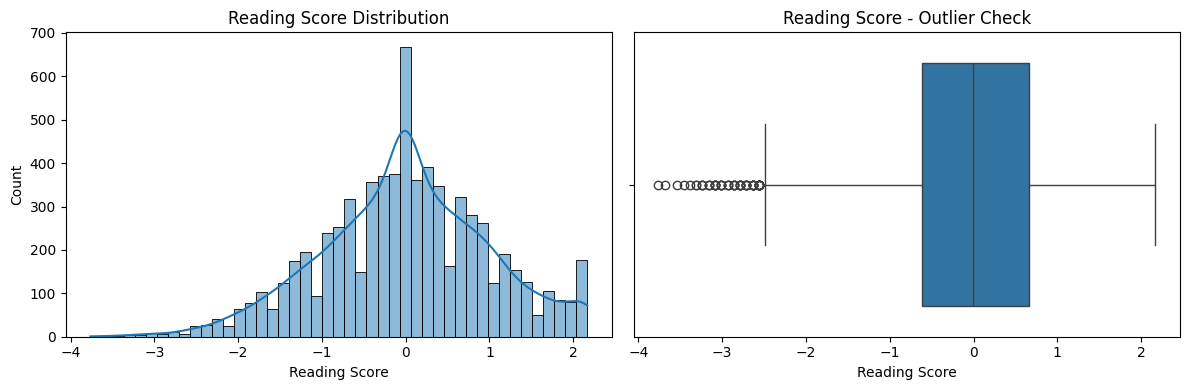

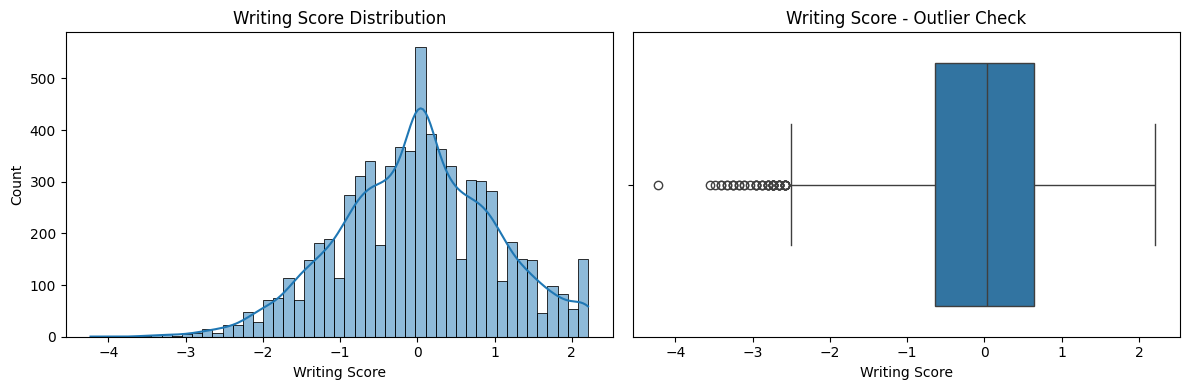

In [17]:
cols = ['Math Score', 'Reading Score', 'Writing Score']

for col in cols:
    fig, axes = plt.subplots(1,2, figsize=(12,4))

    # Histogram
    sns.histplot(data=final_data, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f"{col} Distribution")

    # Boxplot
    sns.boxplot(data=final_data, x=col, ax=axes[1])
    axes[1].set_title(f"{col} - Outlier Check")

    plt.tight_layout()
    plt.show()